<a href="https://colab.research.google.com/github/Arba2021/Arba2021/blob/main/ML_Zoom_Camp_homework4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

In [ ]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv'
!wget $data

--2025-10-18 09:34:26--  https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 80876 (79K) [text/plain]
Saving to: ‘course_lead_scoring.csv.1’

course_lead_scoring 100%[===================>]  78.98K  --.-KB/s    in 0.01s   

2025-10-18 09:34:26 (5.47 MB/s) - ‘course_lead_scoring.csv.1’ saved [80876/80876]



In [ ]:
df = pd.read_csv(data)

In [ ]:
df.columns

Index(['lead_source', 'industry', 'number_of_courses_viewed', 'annual_income',
       'employment_status', 'location', 'interaction_count', 'lead_score',
       'converted'],
      dtype='object')

In [ ]:

df.isna().sum()

,0
lead_source,128
industry,134
number_of_courses_viewed,0
annual_income,181
employment_status,100
location,63
interaction_count,0
lead_score,0
converted,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   object 
 1   industry                  1328 non-null   object 
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   object 
 5   location                  1399 non-null   object 
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 102.9+ KB


In [ ]:
df.head()


,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


In [ ]:
cate_cols = list(df.dtypes[df.dtypes == 'object'].index)
numerical = list(df.dtypes[df.dtypes != 'object'].index)
print(numerical)
cate_cols

['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score', 'converted']


['lead_source', 'industry', 'employment_status', 'location']

In [ ]:
for col in numerical:
  df[col] = df[col].fillna(0.0)
for col in cate_cols:
  df[col] = df[col].fillna('NA')


In [ ]:
for cols in cate_cols:
  print(cols, df[cols].nunique())

lead_source 6
industry 8
employment_status 5
location 8


In [ ]:
df_full_train , df_test = train_test_split(df, test_size = 0.2, random_state = 1)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state=1)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

del df_train['converted']
del df_val['converted']
del df_test['converted']

In [ ]:
numeric = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
scores = {}
for col in numeric:
  auc = roc_auc_score(y_train, df_train[col])
  if auc < 0.5:
    df_train[col] = -df_train[col]
    auc = 1 - auc
  scores[col] = auc
  print(col, auc)

number_of_courses_viewed 0.7635680590007088
annual_income 0.5519578313253012
interaction_count 0.738270176293409
lead_score 0.6144993577250176


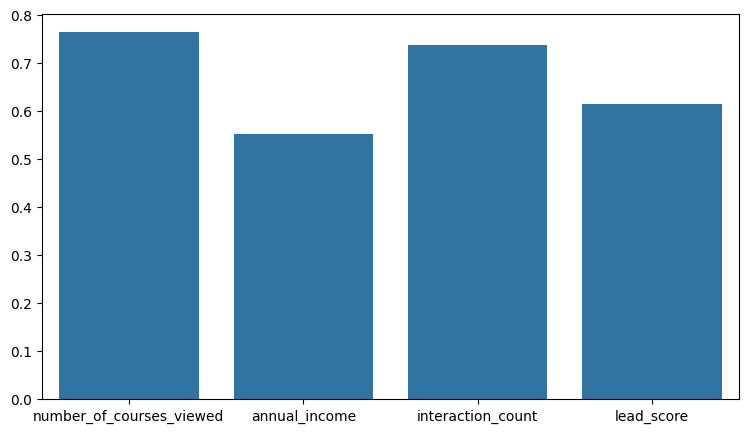

In [ ]:
plt.figure(figsize = (9,5))
sns.barplot(x = list(scores.keys()), y = list(scores.values()))
plt.show()

In [ ]:
num = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']
cate = ['lead_source', 'industry', 'employment_status', 'location']

In [ ]:
dv = DictVectorizer(sparse=False)
train_dict = df_train[num + cate].to_dict(orient='records')
x_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(x_train, y_train)


LogisticRegression(max_iter=1000, solver='liblinear')

In [ ]:

val_dict = df_val[num + cate].to_dict(orient='records')
x_val = dv.transform(val_dict)

In [ ]:
y_pred = model.predict_proba(x_val)[:, 1]
converted_pred = y_pred >= 0.59
acc = (y_val == converted_pred).mean()
round(acc,3)

np.float64(0.754)

In [ ]:
thresholds = np.linspace(0.0, 1.0, 21)
scores = []
for t in thresholds:
  converted_pred = y_pred >= t
  acc = (y_val == converted_pred).mean()
  scores.append(acc)
  print('%0.2f %0.3f' % (t, acc))

0.00 0.584
0.05 0.584
0.10 0.584
0.15 0.584
0.20 0.584
0.25 0.584
0.30 0.594
0.35 0.601
0.40 0.642
0.45 0.679
0.50 0.700
0.55 0.747
0.60 0.747
0.65 0.734
0.70 0.693
0.75 0.655
0.80 0.614
0.85 0.567
0.90 0.495
0.95 0.433
1.00 0.416


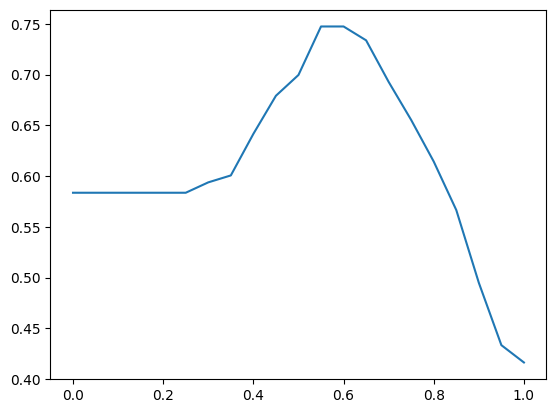

In [110]:
plt.plot(thresholds, scores)
plt.show()

In [ ]:
actual_positive =(y_val == 1)
actual_negative =(y_val == 0)

t = 0.55
predict_positive =(y_pred >= t)
predict_negative =(y_pred < t)
tp = (predict_positive & actual_positive).sum()
tn = (predict_negative & actual_negative).sum()

fp = (predict_positive & actual_negative).sum()
fn = (predict_negative & actual_positive).sum()
confusion_matrix = np.array([
    [tn, fp],
    [fn, tp]
])
confusion_matrix

array([[ 60,  62],
       [ 12, 159]])

In [ ]:
(confusion_matrix / confusion_matrix.sum()).round(2)

array([[0.2 , 0.21],
       [0.04, 0.54]])

In [111]:
p = tp / (tp + fp)
r = tp / (tp + fn)
f1 = 2 * p * r / (p + r)
print(p)
print(r)
round(f1,2)

0.7194570135746606
0.9298245614035088


np.float64(0.81)

In [113]:
scores = []

thresholds = np.linspace(0, 1, 101)

for t in thresholds:
    actual_positive = (y_val == 1)
    actual_negative = (y_val == 0)

    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    scores.append((t, tp, fp, fn, tn))

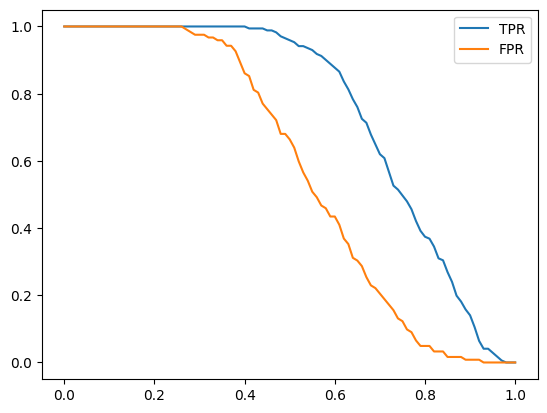

In [114]:
columns = ['threshold', 'tp', 'fp', 'fn', 'tn']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores['tpr'] = df_scores.tp / (df_scores.tp + df_scores.fn)
df_scores['fpr'] = df_scores.fp / (df_scores.fp + df_scores.tn)
plt.plot(df_scores.threshold, df_scores['tpr'], label='TPR')
plt.plot(df_scores.threshold, df_scores['fpr'], label='FPR')
plt.legend()

In [122]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[cate_cols + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model
dv, model = train(df_train, y_train, C=0.001)
def predict(df, dv, model):
    dicts = df[cate_cols+ numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred
y_pred = predict(df_val, dv, model)

In [123]:
n_splits = 5

for C in tqdm([0.001, 0.01, 0.1, 0.5, 1, 5, 10]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

  0%|          | 0/7 [00:00<?, ?it/s]

C=0.001 0.937 +- 0.013
C=0.01 0.989 +- 0.007
C=0.1 1.000 +- 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=0.5 1.000 +- 0.000
C=1 1.000 +- 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


C=5 1.000 +- 0.000
C=10 1.000 +- 0.000
